In [ ]:
#imports 

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from matplotlib.ticker import LogFormatterSciNotation, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg


# Corr Gaussian

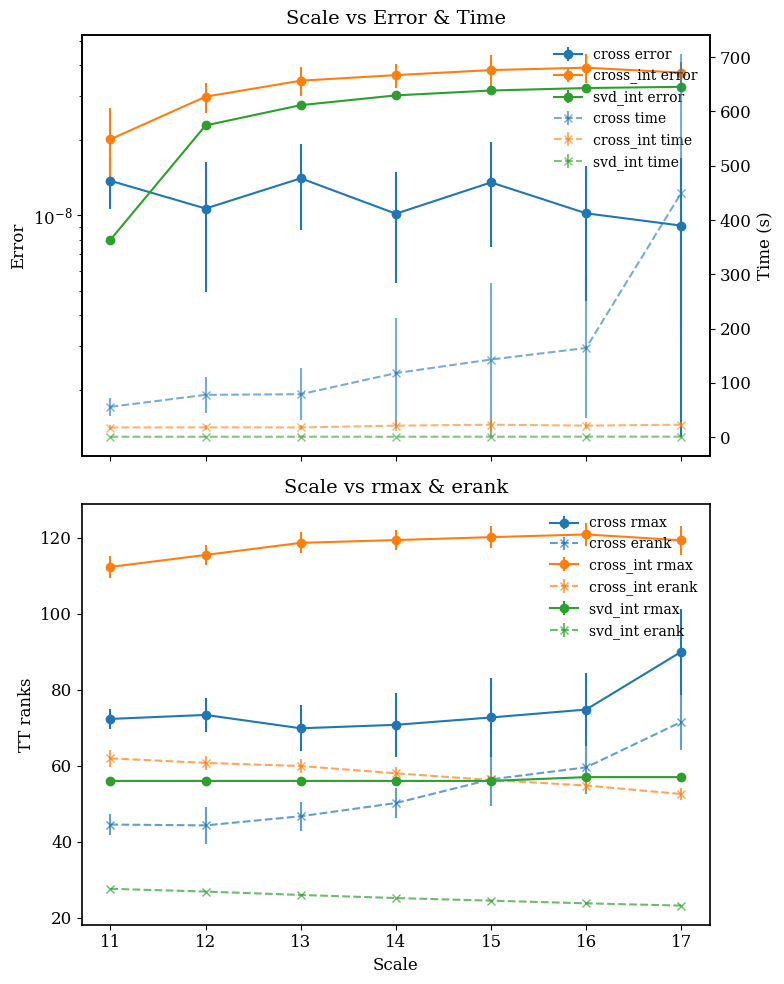

In [23]:
# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
#df = pd.read_csv('./data/corr_gaussian_results.csv')
records = []
with open('./data/corr_gaussian_results_2.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:      # skip empty or whitespace-only lines
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)
stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)
stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

methods = stats['method'].unique()
colors = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
ax2 = ax1.twinx()

# --- Top: Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{method} error',
        color=colors[i]
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{method} time',
        color=colors[i], alpha=0.6
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)',           fontsize=12)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper right', frameon=False, fontsize=10
)

ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# --- Bottom: rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', label=f'{method} rmax',
        color=colors[i]
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', label=f'{method} erank',
        color=colors[i], alpha=0.7
    )

ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('TT ranks', fontsize=12)
ax3.set_title('Scale vs rmax & erank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

ax3.legend(loc='upper right', frameon=False, fontsize=10)

# 4) Thicken spines
for ax in (ax1, ax2, ax3):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()

# 5) Save as PDF for LaTeX
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, 'corr_gaussian_results.pdf'),
    format='pdf', bbox_inches='tight'
)

plt.show()

# Masks

## Circle Mask

/tmp/ipykernel_589570/2334963335.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


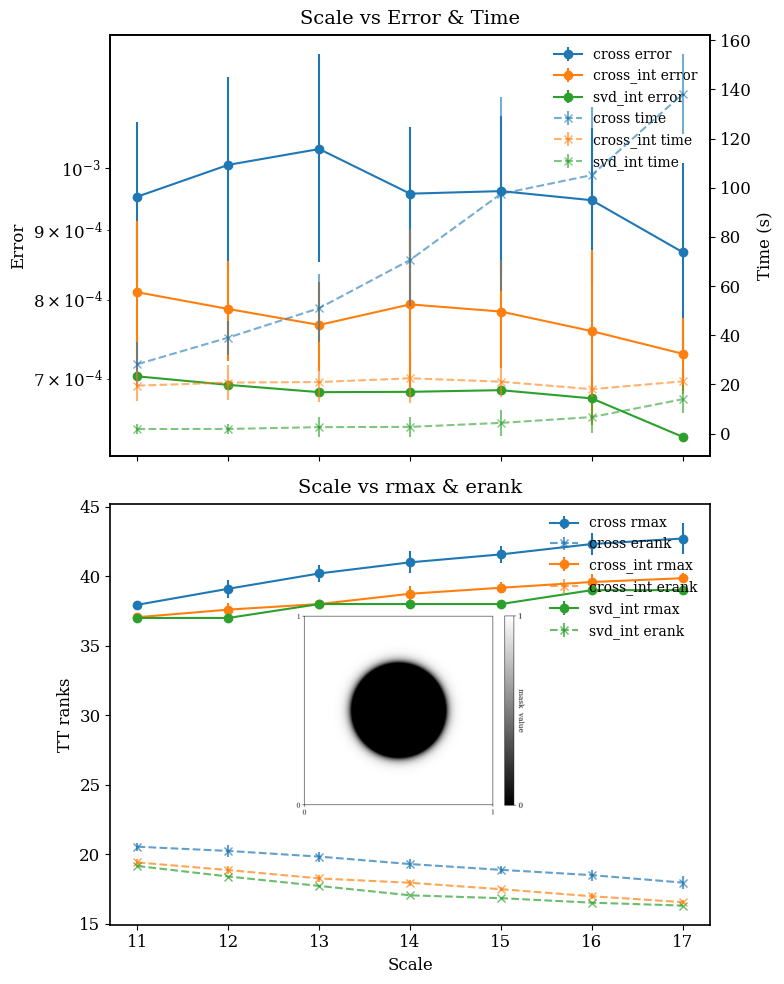

In [14]:
# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
#df = pd.read_csv('./data/mask_results.csv')
records = []
with open('./data/circle_results_lr.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:      # skip empty or whitespace-only lines
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)
stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

methods = stats['method'].unique()
colors = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
ax2 = ax1.twinx()

# --- Top: Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{method} error',
        color=colors[i]
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{method} time',
        color=colors[i], alpha=0.6
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)',           fontsize=12)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper right', frameon=False, fontsize=10
)

ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# --- Bottom: rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', label=f'{method} rmax',
        color=colors[i]
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', label=f'{method} erank',
        color=colors[i], alpha=0.7
    )

ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('TT ranks', fontsize=12)
ax3.set_title('Scale vs rmax & erank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

ax3.legend(loc='upper right', frameon=False, fontsize=10)

# 4) Thicken spines
for ax in (ax1, ax2, ax3):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# read in the image you want to embed
img_mid = mpimg.imread('./figures/circle.png')
# create an inset on ax3, anchored at its center
axins = inset_axes(
    ax3,
    width="50%",    # 30% of the width of ax3
    height="50%",   # 30% of the height of ax3
    loc='center'    # place it at the center of ax3
)

axins.imshow(img_mid)
axins.axis('off')    # hide its axes

# if you want the curves to draw *over* the inset, lower its z‐order:
axins.set_zorder(0)
ax3.set_zorder(1)
ax3.patch.set_visible(False)


plt.tight_layout()

# 5) Save as PDF for LaTeX
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, 'circle_mask_results.pdf'),
    format='pdf', bbox_inches='tight'
)

plt.show()

# Wing Mask

/tmp/ipykernel_589570/4100344935.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


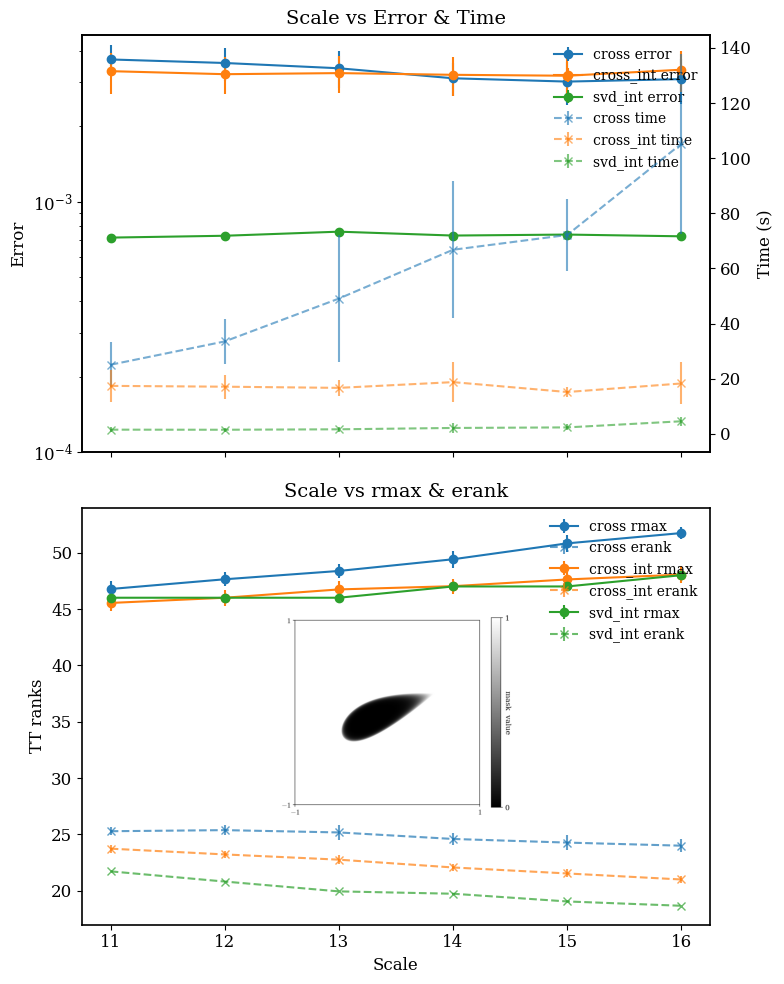

In [13]:
# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
#df = pd.read_csv('./data/mask_results.csv')
records = []
with open('./data/wing_results_lr.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:      # skip empty or whitespace-only lines
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)
stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

methods = stats['method'].unique()
colors = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
ax2 = ax1.twinx()

# --- Top: Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{method} error',
        color=colors[i]
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{method} time',
        color=colors[i], alpha=0.6
    )

ax1.set_yscale('log')
ax1.set_yticks([1e-4, 1e-3])   
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)',           fontsize=12)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper right', frameon=False, fontsize=10
)

ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# --- Bottom: rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', label=f'{method} rmax',
        color=colors[i]
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', label=f'{method} erank',
        color=colors[i], alpha=0.7
    )

ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('TT ranks', fontsize=12)
ax3.set_title('Scale vs rmax & erank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

ax3.legend(loc='upper right', frameon=False, fontsize=10)

# 4) Thicken spines
for ax in (ax1, ax2, ax3):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


# --- after your bottom‐plot and spine‐thickening code ----


# read in the image you want to embed
img_mid = mpimg.imread('./figures/wing.png')
# create an inset on ax3, anchored at its center
axins = inset_axes(
    ax3,
    width="50%",    # 30% of the width of ax3
    height="50%",   # 30% of the height of ax3
    loc='center'    # place it at the center of ax3
)

axins.imshow(img_mid)
axins.axis('off')    # hide its axes

# if you want the curves to draw *over* the inset, lower its z‐order:
axins.set_zorder(0)
ax3.set_zorder(1)
ax3.patch.set_visible(False)

plt.tight_layout()

# 5) Save as PDF for LaTeX
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, 'wing_mask_results.pdf'),
    format='pdf', bbox_inches='tight'
)

plt.show()